In [1]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import statsmodels.api as sm
import scipy
import json
import statsmodels.formula.api as smf
from collections import defaultdict
from scipy.stats import wilcoxon, ttest_rel

from functions import utils, plotting, io, behav_analysis

In [2]:
# pick format to save figures : png for quick visualization, pdf for illustrator
save_as = 'png'
color_dict = {
    'DBS ON': '#20a39e', 
    'DBS OFF': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE',
    'Session 1': "#206ea1", 
    'Session 2': "#5FA363", 
    }
visualize_by = 'subject' # pick whether to visualize by condition (DBS ON, DBS OFF, control) or by subject id


# 1. Select subjects, create color palette and load data #

In [3]:
# Use the Included or excluded.xlsx document:
onedrive_path = utils._get_onedrive_path()

working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

# read the json file containing the included and excluded subjects
# Open and read the JSON file
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)   

In [4]:
included_subjects

['C003 mSST',
 'C004 mSST',
 'C006 mSST',
 'C007 mSST',
 'C008 mSST',
 'C009 mSST',
 'C010 mSST',
 'C011 mSST',
 'C012 mSST',
 'C013 mSST',
 'C014 mSST',
 'C015 mSST',
 'sub006 DBS ON mSST',
 'sub006 DBS OFF mSST',
 'sub011 DBS OFF mSST',
 'sub011 DBS ON mSST',
 'sub012 DBS ON mSST',
 'sub012 DBS OFF mSST',
 'sub015 DBS OFF mSST',
 'sub015 DBS ON mSST',
 'sub019 DBS ON mSST',
 'sub019 DBS OFF mSST',
 'sub023 DBS OFF mSST',
 'sub023 DBS ON mSST',
 'sub025 DBS ON mSST',
 'sub025 DBS OFF mSST',
 'sub027 DBS ON mSST',
 'sub027 DBS OFF mSST',
 'sub028 DBS OFF mSST',
 'sub028 DBS ON mSST',
 'sub029 DBS ON mSST',
 'sub029 DBS OFF mSST',
 'sub032 DBS ON mSST',
 'sub032 DBS OFF mSST',
 'sub033 DBS ON mSST',
 'sub033 DBS OFF mSST']

In [5]:
subject_colors = utils.create_color_palette(included_subjects)
utils.plot_color_palette(
    subject_colors = subject_colors,
    save_as='png', 
    saving_path=behav_results_saving_path
    )

['C003', 'C004', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014', 'C015', 'sub006', 'sub011', 'sub012', 'sub015', 'sub019', 'sub023', 'sub025', 'sub027', 'sub028', 'sub029', 'sub032', 'sub033']


In [6]:
# load excel files for all included subjects and extract stats
data = io.load_behav_data(included_subjects, onedrive_path)
stats = utils.extract_stats(data)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
C013 mSST
C014 mSST
C015 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub012 DBS ON mSST
sub012 DBS OFF mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST
C003 mSST # GC RTs:80 # Continue signal delay 80
C004 mSST # GC RTs:60 # Continue signal delay 60
C006 mSST # GC RTs:64 # Continue signal delay 64
C007 mSST # GC RTs:60 # Continue signal delay 60
C008 mSST # GC RTs:59 # Continue signal delay 59
C009 mSST # GC RTs:60 # Continue signal delay 60
C010 mSST # GC RTs:57 # Continue signal delay 57
C011 mSST # GC RTs:59 # Continue signal delay 59
C012 mSST # GC RTs:5

In [7]:
# fetch excel file containing recording and subject information
excel_file = join(onedrive_path, 'WP3_rec_info.xlsx')
# select the relevant sheet called 'Subjects List'
subject_info_df = pd.read_excel(excel_file, sheet_name='Subjects List')
control_info_df = pd.read_excel(excel_file, sheet_name='Controls List')

# get session order and save it to 'session_info.txt'
behav_analysis.get_session_order(
    included_subjects = included_subjects,
    subject_info_df = subject_info_df,
    behav_results_saving_path = behav_results_saving_path
)

6 subjects started with first session in OFF condition
6 subjects started with first session in ON condition


# 2. Visualize performance per trial type and condition/subject #

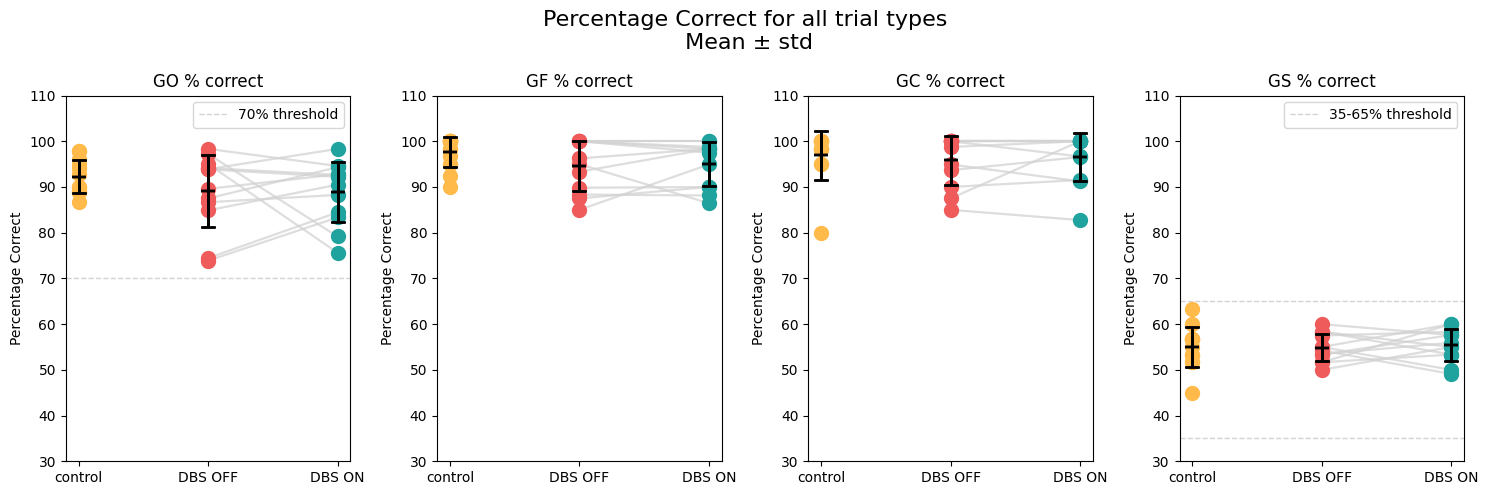

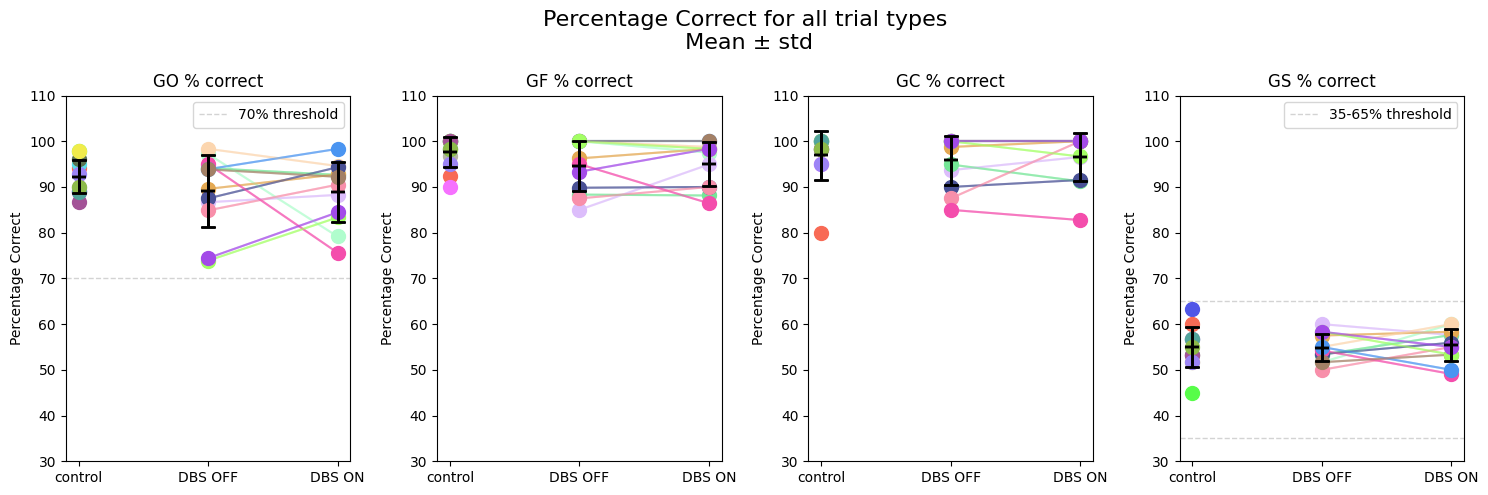

In [10]:
temp_save = join(behav_results_saving_path, "Performance")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)   
for color in ['condition', 'subject']:
    behav_analysis.plot_perf_all(
        stats = stats,
        color_dict = color_dict,
        subject_colors = subject_colors,
        colored_by = color,
        saving_path = temp_save,
        save_as = save_as,
        show_plot = True
    )    

# 3. Visualize early presses #

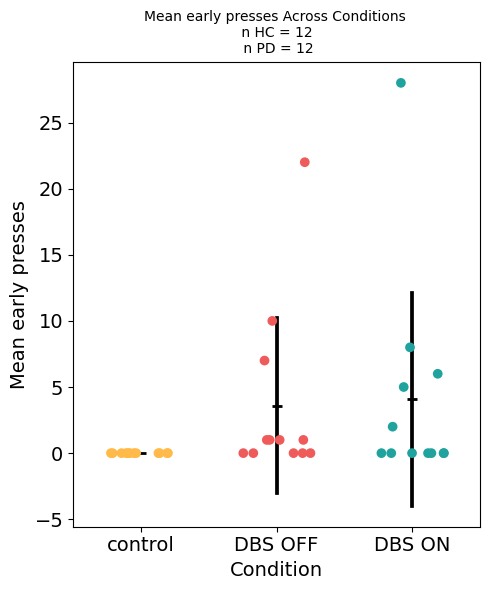

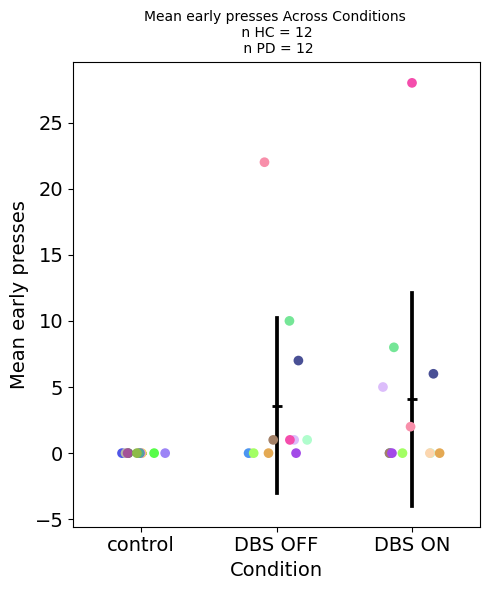

In [16]:
temp_save = join(behav_results_saving_path, "Performance")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  
variable_of_interest = 'early presses'        
for color in ['condition', 'subject']:
    behav_analysis.plot_variable_of_interest(
        stats = stats,
        color_dict = color_dict,
        subject_colors = subject_colors,
        variable_of_interest = variable_of_interest,
        colored_by = color,
        saving_path = temp_save,
        save_as = save_as,
        show_plot = True
    )   

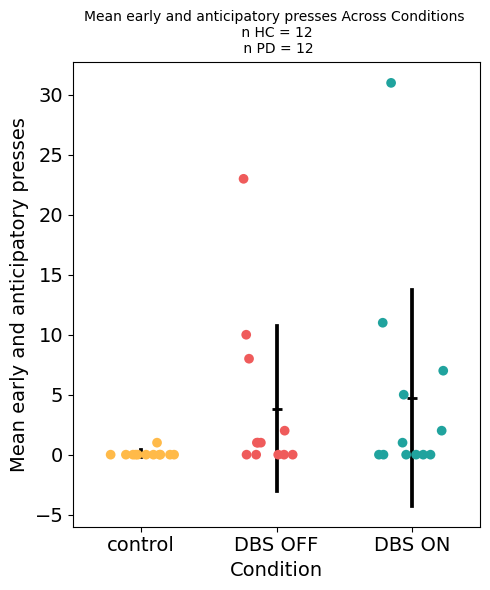

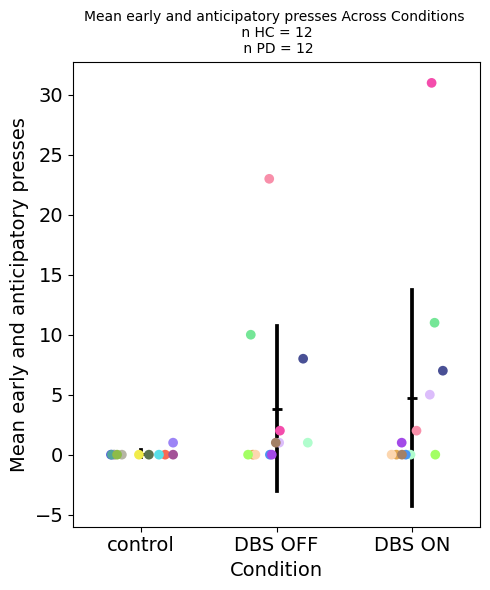

In [ ]:
# Also include anticipatory presses in the analysis, not only early presses, 
# as they are both considered impulsive responses.
# Here we consider RT < 200ms as anticipatory presses. 
# Early presses are presses before the square (GO) cue.

temp_save = join(behav_results_saving_path, "Performance")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  
variable_of_interest = 'early and anticipatory presses'        
for color in ['condition', 'subject']:
    behav_analysis.plot_variable_of_interest(
        stats = stats,
        color_dict = color_dict,
        subject_colors = subject_colors,
        variable_of_interest = variable_of_interest,
        colored_by = color,
        saving_path = temp_save,
        save_as = save_as,
        show_plot = True
    )   